In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Load dataset
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

In [21]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [22]:
# Reduce dimensionality for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

SINGLE Linkage Silhouette Score: 0.6607
COMPLETE Linkage Silhouette Score: 0.6607
AVERAGE Linkage Silhouette Score: 0.634


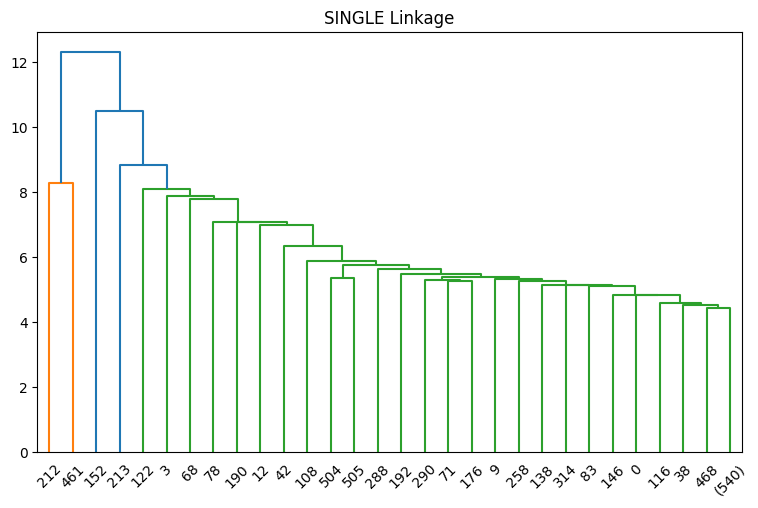

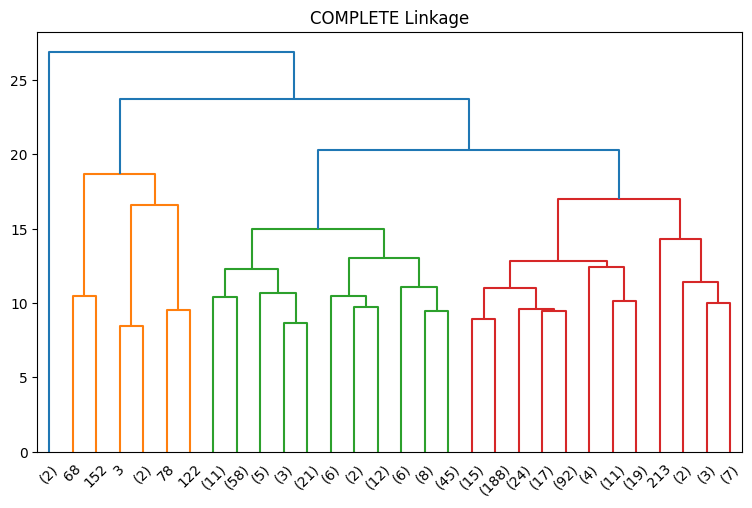

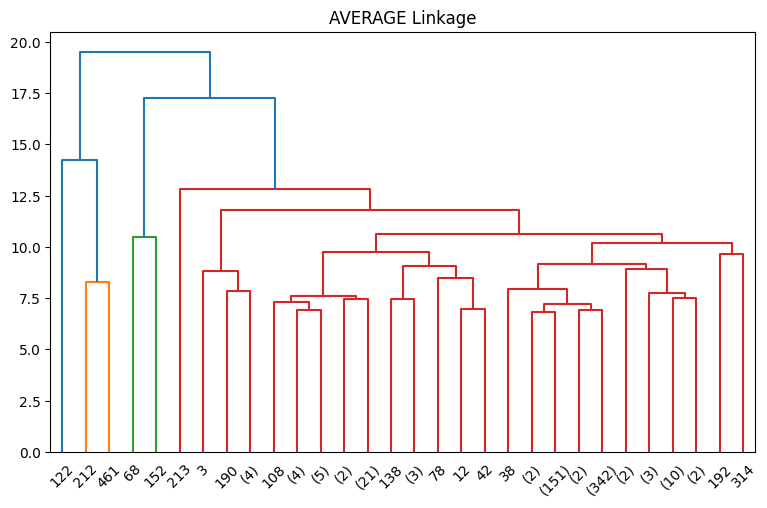

In [23]:
# ONLY THIS PART ADDED
methods = ['single', 'complete', 'average']

for i in range(len(methods)):
    method = methods[i]

    # Clustering (ONLY linkage changes)
    agg_clustering = AgglomerativeClustering(n_clusters=2, linkage=method)
    cluster_labels = agg_clustering.fit_predict(X_scaled)

    # Create figure 
    plt.figure(figsize=(20, 12))
    # Dendrogram (ONLY method changes)
    plt.subplot(2, 2, i+1)
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, truncate_mode='lastp', p=30)

    plt.title(method.upper() + " Linkage")

    # Silhouette Score
    score = silhouette_score(X_scaled, cluster_labels)
    print(method.upper(), "Linkage Silhouette Score:", round(score, 4))


In [24]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>